In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import math

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import linkage, dendrogram
from kneed import KneeLocator
print('Setup complete.')

Setup complete.


In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df_raw = pd.read_excel(url, engine='openpyxl')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['Revenue'] = df_raw['Quantity'] * df_raw['UnitPrice']
print(f'Loaded: {df_raw.shape[0]:,} rows')
df_raw.head(3)

Loaded: 541,909 rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

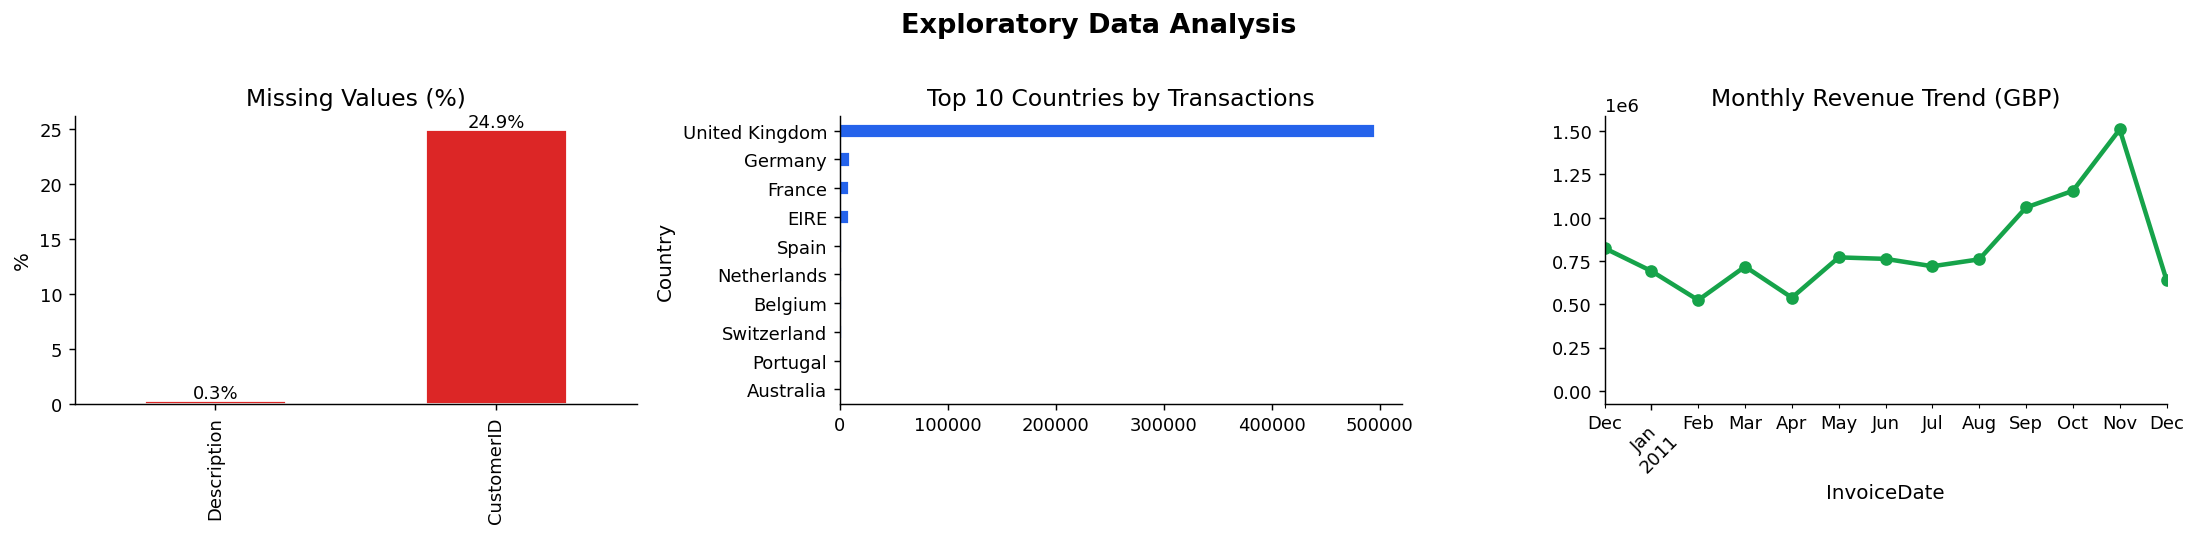

UK: 91.4% of transactions


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

miss = df_raw.isnull().mean() * 100
miss[miss > 0].plot(kind='bar', ax=axes[0], color='#DC2626', edgecolor='white')
axes[0].set_title('Missing Values (%)')
axes[0].set_ylabel('%')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                     ha='center', fontsize=10)

df_raw['Country'].value_counts().head(10).plot(
    kind='barh', ax=axes[1], color='#2563EB', edgecolor='white')
axes[1].set_title('Top 10 Countries by Transactions')
axes[1].invert_yaxis()

monthly = (df_raw[df_raw['Revenue'] > 0]
           .groupby(df_raw['InvoiceDate'].dt.to_period('M'))['Revenue'].sum())
monthly.plot(ax=axes[2], color='#16A34A', marker='o', linewidth=2.5)
axes[2].fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#16A34A')
axes[2].set_title('Monthly Revenue Trend (GBP)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'UK: {df_raw[df_raw["Country"]=="United Kingdom"].shape[0]/df_raw.shape[0]*100:.1f}% of transactions')

In [ ]:
def clean_data(df):

    n0 = len(df)
    steps = {}
    df = df.dropna(subset=['CustomerID', 'Description'])
    steps['Missing CustomerID/Desc'] = n0 - len(df)
    df['CustomerID'] = df['CustomerID'].astype(int)

    n1 = len(df)
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
    steps['Cancellations'] = n1 - len(df)

    n2 = len(df)
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    steps['Invalid Qty/Price'] = n2 - len(df)

    non_product = ['POST','D','M','BANK CHARGES','PADS','DOT','AMAZONFEE','CRUK']
    n3 = len(df)
    df = df[~df['StockCode'].astype(str).str.upper().isin(non_product)]
    steps['Non-product codes'] = n3 - len(df)

    n4 = len(df)
    df = df[df['Country'] == 'United Kingdom']
    steps['Non-UK'] = n4 - len(df)

    n5 = len(df)
    df = df.drop_duplicates()
    steps['Duplicates'] = n5 - len(df)

    df['Total'] = df['Quantity'] * df['UnitPrice']
    print('Cleaning summary:')
    for step, count in steps.items():
        print(f'  {step:<25}: {count:>6,} rows removed')
    print(f'  Final: {len(df):,} rows | {df["CustomerID"].nunique():,} customers')
    return df.reset_index(drop=True)

df = clean_data(df_raw.copy())

Cleaning summary:
  Missing CustomerID/Desc  : 135,080 rows removed
  Cancellations            :  8,905 rows removed
  Invalid Qty/Price        :     40 rows removed
  Non-product codes        :  1,414 rows removed
  Non-UK                   : 42,455 rows removed
  Duplicates               :  5,113 rows removed
  Final: 348,902 rows | 3,916 customers


In [ ]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    recency   = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    frequency = ('InvoiceNo',   'nunique'),
    monetary  = ('Total',       'sum')
).reset_index()

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

basket = (df.groupby(['CustomerID','InvoiceNo'])['Quantity']
            .sum().groupby('CustomerID').mean())
rfm = rfm.set_index('CustomerID')
rfm['avg_basket_size'] = basket
rfm['unique_products'] = df.groupby('CustomerID')['StockCode'].nunique()

span = df.groupby('CustomerID')['InvoiceDate'].agg(
    lambda x: (x.max() - x.min()).days)
rfm['purchase_span'] = span



rfm = rfm.fillna(0)
print(f'RFM matrix: {rfm.shape[0]:,} customers x {rfm.shape[1]} features')
rfm.describe().round(2)

RFM matrix: 3,916 customers x 9 features


,recency,frequency,monetary,avg_order_value,avg_basket_size,unique_products,purchase_span,purchase_rate,clv_proxy
count,3916.00,3916.00,3916.00,3916.00,3916.00,3916.00,3916.00,3916.00,3916.00
mean,92.35,4.23,1849.93,391.74,243.14,60.73,130.88,1.22,1849.93
std,99.72,7.16,7432.63,1870.78,1374.77,81.62,132.30,0.75,7432.63
min,1.00,1.00,3.75,3.75,1.00,1.00,0.00,1.00,3.75
25%,18.00,1.00,298.08,173.83,90.00,15.00,0.00,1.00,298.08
50%,51.00,2.00,644.97,279.26,155.00,35.00,93.00,1.00,644.97
75%,143.00,5.00,1567.53,408.84,260.00,77.00,252.00,1.25,1567.53
max,374.00,206.00,259657.30,84236.25,74215.00,1766.00,373.00,34.00,259657.30


In [ ]:
def preprocess_rfm(rfm):

    feat = rfm[['recency','frequency','monetary']].copy()
    feat = np.log1p(feat)

    scaler = RobustScaler()
    X = scaler.fit_transform(feat)
    print(f'Clustering input: {X.shape}')
    return X, feat.index, scaler

X, valid_idx, scaler = preprocess_rfm(rfm)

In [ ]:
K_range = range(2, 12)
inertias, sil_scores, dbi_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    dbi_scores.append(davies_bouldin_score(X, labels))
    print(f'k={k:2d}  Sil={sil_scores[-1]:.4f}  DBI={dbi_scores[-1]:.4f}')

kl = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
knee_k = kl.knee

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertias, 'o-', color='#2563EB', linewidth=2.5)
if knee_k:
    axes[0].axvline(knee_k, linestyle='--', color='red', label=f'Elbow k={knee_k}')
axes[0].axvline(4, linestyle=':', color='green', linewidth=2, label='Selected k=4')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(K_range)
axes[1].axvline(4, linestyle=':', color='green', linewidth=2, label='Selected k=4')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].legend()

axes[2].plot(K_range)
axes[2].axvline(4)
axes[2].set_title('Davies-Bouldin Index'); axes[2].set_xlabel('k'); axes[2].legend()

plt.suptitle('Optimal k Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Decision: k=4 — maps to Champions, Loyal, At-Risk, Lost)

In [ ]:
N_CLUSTERS = 4
km_final = KMeans(n_clusters=N_CLUSTERS, init='k-means++',
                  n_init=50, max_iter=500, random_state=42)
cluster_labels = km_final.fit_predict(X)

sil = silhouette_score(X, cluster_labels)
dbi = davies_bouldin_score(X, cluster_labels)
chi = calinski_harabasz_score(X, cluster_labels)

print(f'Silhouette Score       : {sil:.4f}  (higher=better)')
print(f'Davies-Bouldin Index   : {dbi:.4f}  (lower=better)')
print(f'Calinski-Harabasz Index: {chi:,.1f}  (higher=better)')

rfm_clustered = rfm.loc[valid_idx].copy()
rfm_clustered['cluster'] = cluster_labels

cluster_profile = rfm_clustered.groupby('cluster').agg(
    recency   = ('recency',   'median'),
    frequency = ('frequency', 'median'),
    monetary  = ('monetary',  'median'),
    rfm_score = ('RFM_Score', 'median'),
    n         = ('recency',   'count')
).sort_values('rfm_score', ascending=False)

cluster_profile['rank'] = range(len(cluster_profile))
segment_names = ['Champions','Loyal Customers','At-Risk Customers','Lost / Inactive']
rank_to_name  = dict(zip(cluster_profile['rank'], segment_names))
cluster_to_name = {c: rank_to_name[r] for c, r in cluster_profile['rank'].items()}

rfm_clustered['segment'] = rfm_clustered['cluster'].map(cluster_to_name)
print('\nSegment mapping:')
for c, name in cluster_to_name.items():
    row = cluster_profile.loc[c]
    print(f'  Cluster {c} -> {name:<22} | Rec={row["recency"]:.0f}d | Freq={row["frequency"]:.0f} | Mon=GBP{row["monetary"]:,.0f} | n={row["n"]:,}')

Silhouette Score       : 0.3361  (higher=better)
Davies-Bouldin Index   : 1.0089  (lower=better)
Calinski-Harabasz Index: 3,105.0  (higher=better)

Segment mapping:
  Cluster 3 -> Champions              | Rec=10d | Freq=8 | Mon=GBP2,711 | n=745.0
  Cluster 0 -> Loyal Customers        | Rec=61d | Freq=3 | Mon=GBP1,099 | n=1,040.0
  Cluster 2 -> At-Risk Customers      | Rec=18d | Freq=2 | Mon=GBP399 | n=692.0
  Cluster 1 -> Lost / Inactive        | Rec=178d | Freq=1 | Mon=GBP270 | n=1,285.0


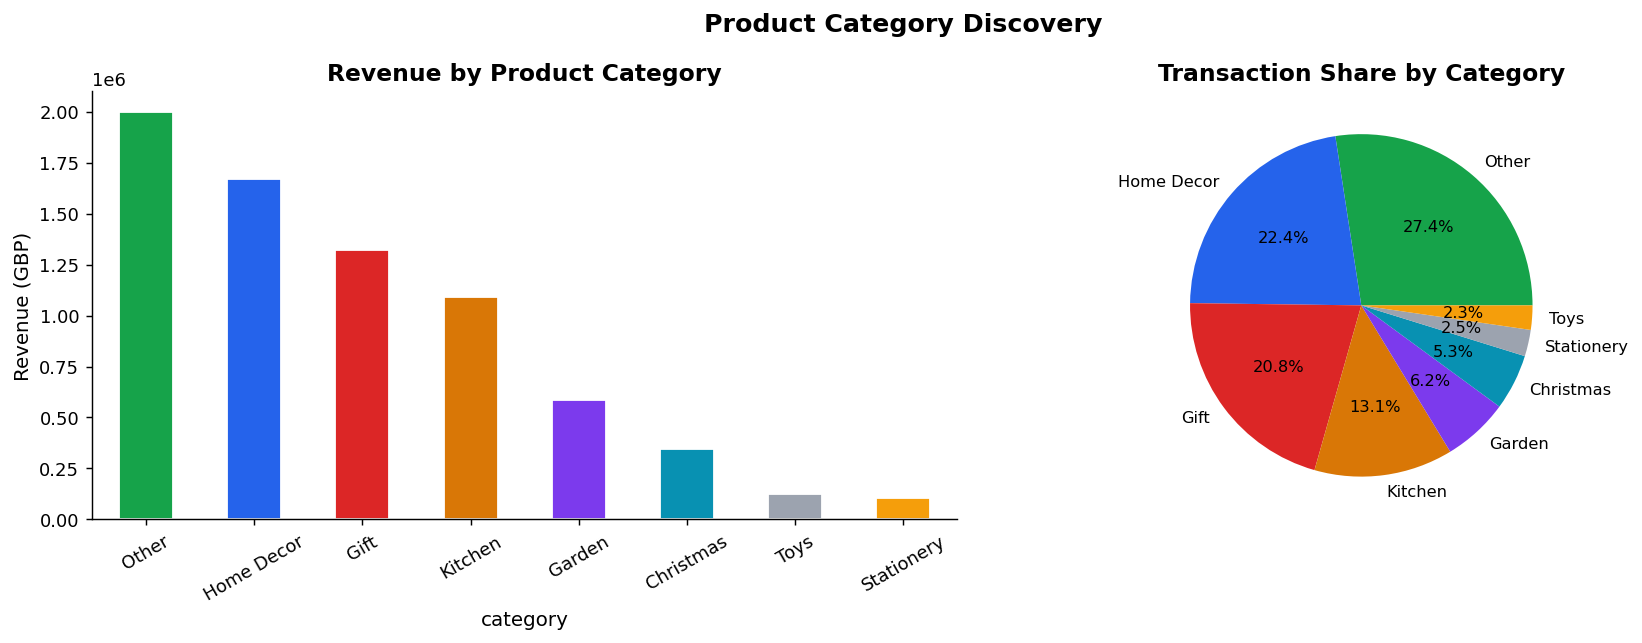

Category revenue breakdown:
  Other       : GBP  1,999,913  (27.6%)
  Home Decor  : GBP  1,670,130  (23.1%)
  Gift        : GBP  1,319,607  (18.2%)
  Kitchen     : GBP  1,092,549  (15.1%)
  Garden      : GBP    586,533  (8.1%)
  Christmas   : GBP    343,731  (4.7%)
  Toys        : GBP    126,717  (1.7%)
  Stationery  : GBP    105,151  (1.5%)


In [ ]:

CATEGORY_KEYWORDS = {
    'Christmas'  : ['christmas','xmas','santa','reindeer','advent','festive','noel'],
    'Gift'       : ['gift','wrap','ribbon','bow','bag','tag','card','packaging','tissue'],
    'Home Decor' : ['heart','vintage','shabby','bunting','garland','lantern','candle',
                    'frame','mirror','cushion','throw','sign','plaque'],
    'Kitchen'    : ['mug','cup','teapot','tin','cake','baking','kitchen','pantry',
                    'storage','jar','bottle','spoon'],
    'Garden'     : ['garden','bird','outdoor','plant','pot','seed','watering'],
    'Toys'       : ['toy','game','play','doll','teddy','children','kids','nursery'],
    'Stationery' : ['notebook','diary','pen','pencil','sticker','rubber','ruler',
                    'notepad','letter','postcard'],
}

def categorise_product(desc):
    """Assign a product to its primary category based on description keywords."""
    if not isinstance(desc, str):
        return 'Other'
    d = desc.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in d for kw in keywords):
            return category
    return 'Other'

df['category'] = df['Description'].apply(categorise_product)

# Distribution of categories
cat_dist = df.groupby('category')['Total'].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_dist.plot(kind='bar', ax=axes[0])
axes[0].set_title('Revenue by Product Category', fontweight='bold')
axes[0].set_ylabel('Revenue (GBP)')
axes[0].tick_params(axis='x', rotation=30)

df['category'].value_counts().plot(kind='pie', ax=axes[1])
axes[1].set_title('Transaction Share by Category', fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Product Category Discovery', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Category revenue breakdown:')
for cat, rev in cat_dist.items():
    pct = rev / cat_dist.sum() * 100
    print(f'  {cat:<12}: GBP {rev:>10,.0f}  ({pct:.1f}%)')

In [ ]:

cat_spend = (df.groupby(['CustomerID','category'])['Total']
               .sum()
               .unstack(fill_value=0))

cat_pct = cat_spend.div(cat_spend.sum(axis=1), axis=0) * 100
cat_pct.columns = [f'pct_{c.lower().replace(" ","_")}' for c in cat_pct.columns]

rfm_clustered = rfm_clustered.join(cat_pct, how='left').fillna(0)

print('Customer category spend features added:')
print([c for c in rfm_clustered.columns if c.startswith('pct_')])
print(f'\nSample (top 5 customers):')
pct_cols = [c for c in rfm_clustered.columns if c.startswith('pct_')]
display(rfm_clustered[pct_cols].head())

Customer category spend features added:
['pct_christmas', 'pct_garden', 'pct_gift', 'pct_home_decor', 'pct_kitchen', 'pct_other', 'pct_stationery', 'pct_toys']

Sample (top 5 customers):


,pct_christmas,pct_garden,pct_gift,pct_home_decor,pct_kitchen,pct_other,pct_stationery,pct_toys
CustomerID,,,,,,,,
12747,0.000000,7.714472,9.170617,23.117199,0.972352,56.179799,2.845560,0.00000
12749,0.789561,3.685515,11.836818,21.816822,33.041057,28.030888,0.799339,0.00000
12820,27.949572,0.000000,24.122928,20.809899,14.644396,12.473205,0.000000,0.00000
12821,0.000000,0.000000,0.000000,81.665229,18.334771,0.000000,0.000000,0.00000
12822,22.519181,0.000000,23.672119,22.573982,18.116095,3.148976,7.545738,2.42391


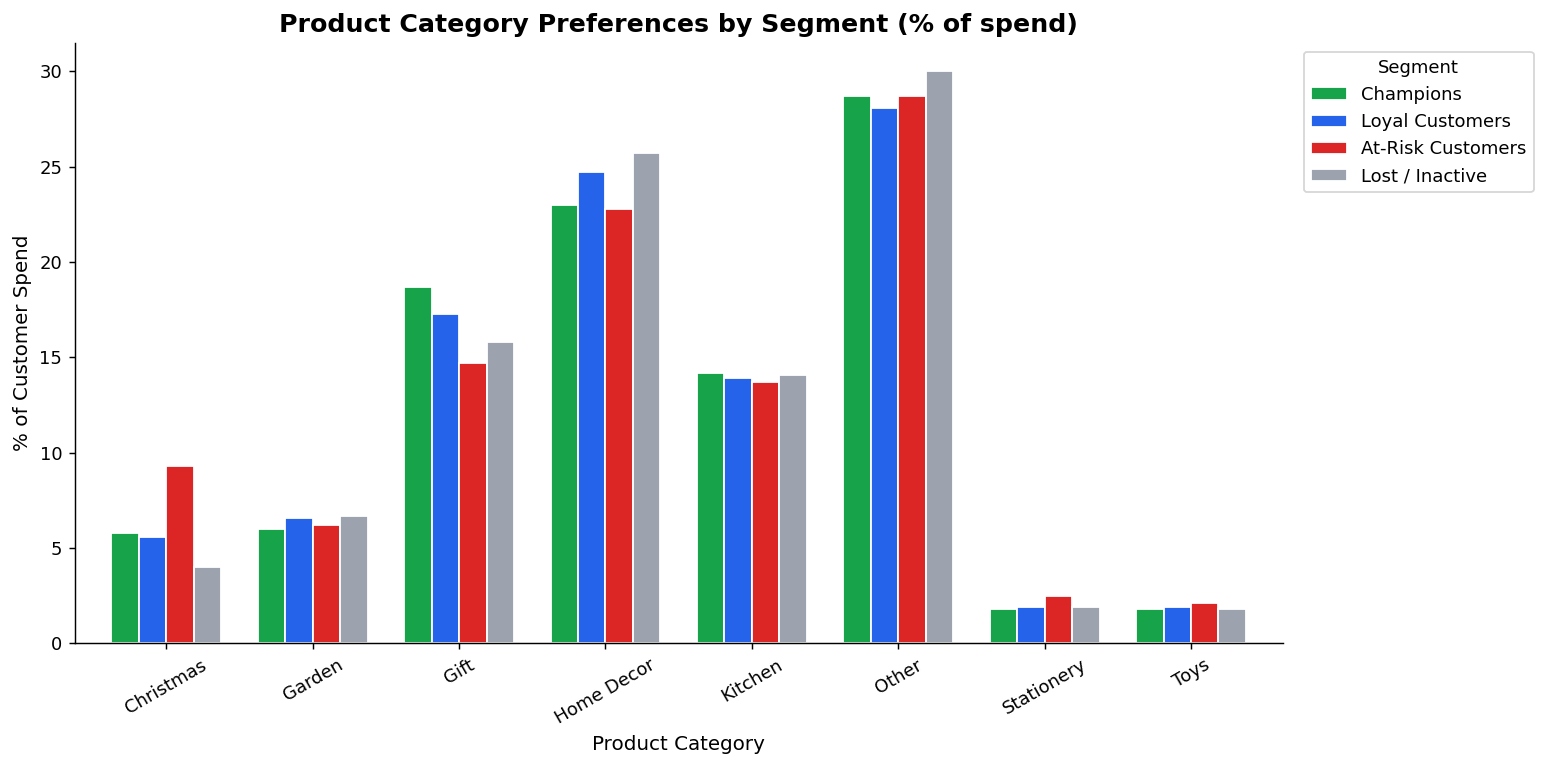

Category preferences per segment:


,Christmas,Garden,Gift,Home Decor,Kitchen,Other,Stationery,Toys
segment,,,,,,,,
Champions,5.8,6.0,18.7,23.0,14.2,28.7,1.8,1.8
Loyal Customers,5.6,6.6,17.3,24.7,13.9,28.1,1.9,1.9
At-Risk Customers,9.3,6.2,14.7,22.8,13.7,28.7,2.5,2.1
Lost / Inactive,4.0,6.7,15.8,25.7,14.1,30.0,1.9,1.8


In [ ]:

pct_cols = [c for c in rfm_clustered.columns if c.startswith('pct_')]
cat_by_seg = rfm_clustered.groupby('segment')[pct_cols].mean().round(1)
cat_by_seg.columns = [c.replace('pct_','').replace('_',' ').title() for c in cat_by_seg.columns]
cat_by_seg = cat_by_seg.reindex(segment_names)

fig, ax = plt.subplots(figsize=(12, 6))
cat_by_seg.T.plot(kind='bar', ax=ax,
                  color=[SEG_COLORS[s] for s in segment_names],
                  edgecolor='white', width=0.75)
ax.set_title('Product Category Preferences by Segment (% of spend)', fontweight='bold', fontsize=14)
ax.set_ylabel('% of Customer Spend')
ax.set_xlabel('Product Category')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Category preferences per segment:')
display(cat_by_seg)

In [ ]:
def sub_cluster_segment(rfm_clustered, segment_name, pct_cols, n_sub=3):

    seg_df = rfm_clustered[rfm_clustered['segment'] == segment_name][pct_cols].copy()
    if len(seg_df) < n_sub * 10:
        print(f'  {segment_name}: too few customers for sub-clustering')
        return None, None

    scaler_sub = RobustScaler()
    X_sub = scaler_sub.fit_transform(seg_df)

    # Pick best k by silhouette
    best_k, best_sil, best_labels = 2, -1, None
    for k in range(2, min(5, len(seg_df)//20 + 2)):
        km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
        labs = km.fit_predict(X_sub)
        s = silhouette_score(X_sub, labs)
        if s > best_sil:
            best_k, best_sil, best_labels = k, s, labs

    print(f'  {segment_name}: {best_k} sub-clusters (Silhouette={best_sil:.3f})')
    return best_labels, seg_df.index

pct_cols = [c for c in rfm_clustered.columns if c.startswith('pct_')]

print('Sub-clustering high-value segments by product preference:')
rfm_clustered['sub_cluster'] = 'N/A'
rfm_clustered['sub_segment'] = rfm_clustered['segment']

# Sub-cluster Champions and Loyal Customers
for seg in ['Champions', 'Loyal Customers']:
    labels, idx = sub_cluster_segment(rfm_clustered, seg, pct_cols)
    if labels is not None:
        rfm_clustered.loc[idx, 'sub_cluster'] = labels

        # Name sub-clusters by their top category
        sub_profiles = rfm_clustered.loc[idx].groupby('sub_cluster')[pct_cols].mean()
        for sc in sub_profiles.index:
            top_cat = sub_profiles.loc[sc].idxmax().replace('pct_','').replace('_',' ').title()
            mask = (rfm_clustered.index.isin(idx)) & (rfm_clustered['sub_cluster'] == sc)
            rfm_clustered.loc[mask, 'sub_segment'] = f'{seg} — {top_cat} Buyers'

print('\nSub-segments created:')
print(rfm_clustered['sub_segment'].value_counts().to_string())

Sub-clustering high-value segments by product preference:
  Champions: 3 sub-clusters (Silhouette=0.165)
  Loyal Customers: 2 sub-clusters (Silhouette=0.517)

Sub-segments created:
sub_segment
Lost / Inactive                   1285
Loyal Customers — Other Buyers    1040
At-Risk Customers                  692
Champions — Other Buyers           508
Champions — Gift Buyers            237


Sub-Segment Profile (Champions + Loyal only):


,Customers,Avg_Recency,Avg_Freq,Avg_Spend,Total_Rev,Revenue_Share_%
sub_segment,,,,,,
Champions — Other Buyers,508,10.0,8.0,2617.3,1685435.2,43.0
Loyal Customers — Other Buyers,1040,61.0,3.0,1098.6,1382675.6,35.3
Champions — Gift Buyers,237,10.0,8.0,2915.2,849178.7,21.7


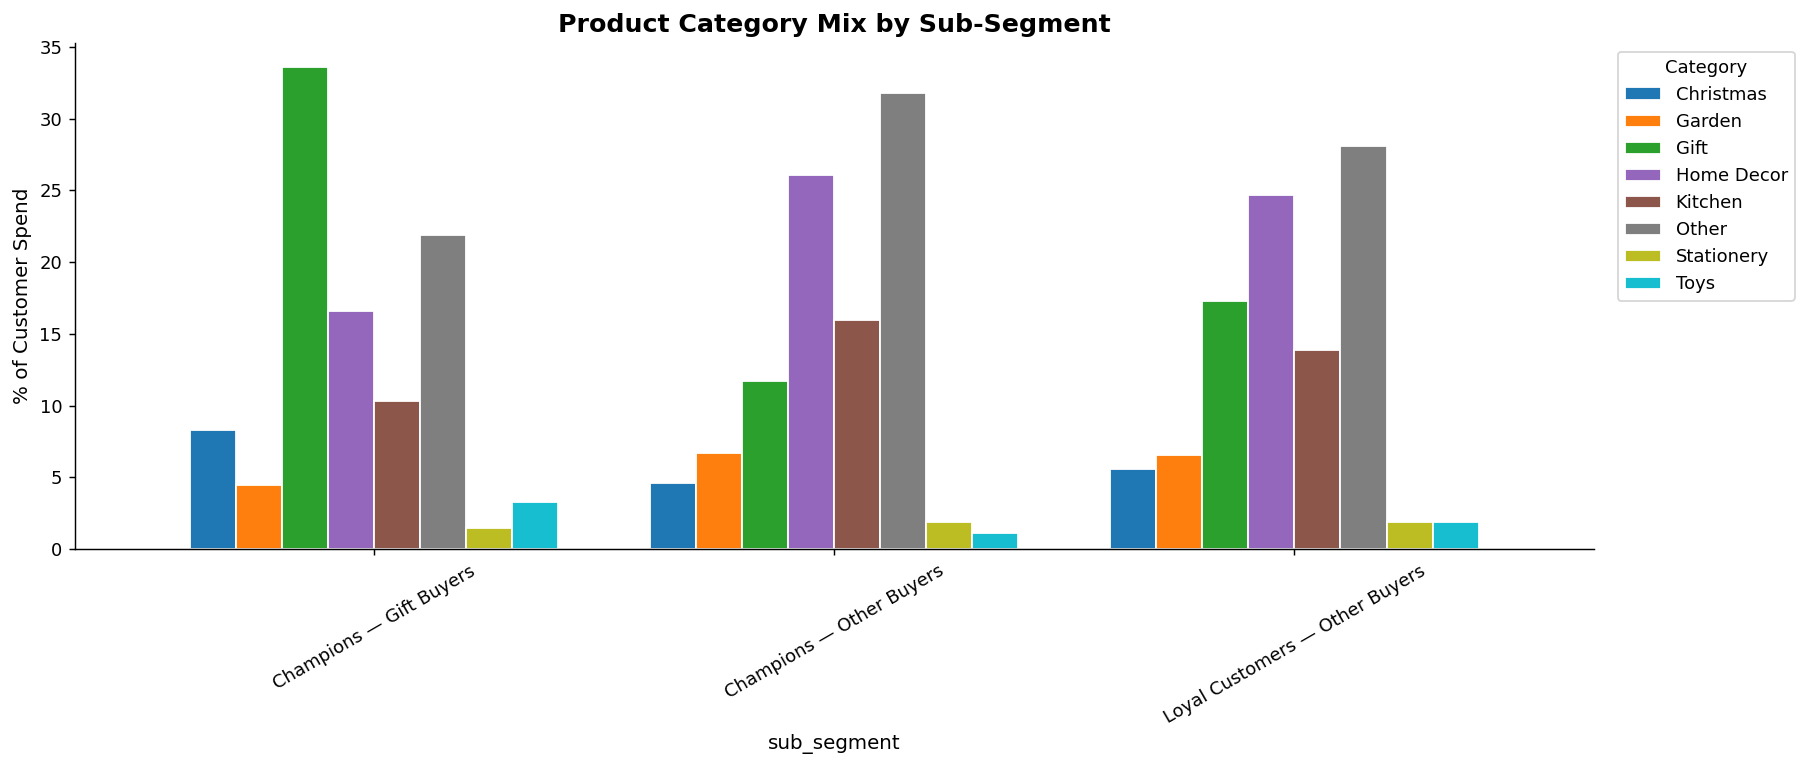

In [ ]:

sub_segs = rfm_clustered[rfm_clustered['segment'].isin(['Champions','Loyal Customers'])]
sub_profile = sub_segs.groupby('sub_segment').agg(
    Customers   = ('recency',   'count'),
    Avg_Recency = ('recency',   'median'),
    Avg_Freq    = ('frequency', 'median'),
    Avg_Spend   = ('monetary',  'median'),
    Total_Rev   = ('monetary',  'sum'),
).round(1)
sub_profile['Revenue_Share_%'] = (sub_profile['Total_Rev'] / sub_profile['Total_Rev'].sum() * 100).round(1)
sub_profile = sub_profile.sort_values('Total_Rev', ascending=False)

print('Sub-Segment Profile (Champions + Loyal only):')
display(sub_profile)

# Visualise category breakdown per sub-segment
sub_cat = sub_segs.groupby('sub_segment')[pct_cols].mean().round(1)
sub_cat.columns = [c.replace('pct_','').replace('_',' ').title() for c in sub_cat.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sub_cat.plot(kind='bar')
ax.set_title('Product Category Mix by Sub-Segment')
ax.set_ylabel('% of Customer Spend')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
summary = rfm_clustered.groupby('segment').agg(
    Customers        = ('recency', 'count'),
    Median_Recency   = ('recency', 'median'),
    Median_Frequency = ('frequency', 'median'),
    Median_Spend     = ('monetary', 'median'),
    Avg_Order_Value  = ('avg_order_value', 'median'),
    Unique_Products  = ('unique_products', 'median'),
    Total_Revenue    = ('monetary', 'sum'),
    Avg_CLV          = ('clv_proxy', 'median'),
).round(2)

summary['Revenue_Share_%'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
summary = summary.reindex(segment_names)

print('COMPLETE SEGMENT PROFILE TABLE')
print('=' * 90)
display(summary)

COMPLETE SEGMENT PROFILE TABLE


,Customers,Median_Recency,Median_Frequency,Median_Spend,Avg_Order_Value,Unique_Products,Total_Revenue,Avg_CLV,Revenue_Share_%
segment,,,,,,,,,
Champions,745,10.0,8.0,2711.11,337.14,107.0,2534613.95,2711.11,54.8
Loyal Customers,1040,61.0,3.0,1098.60,345.81,53.0,1382675.58,1098.60,29.9
At-Risk Customers,692,18.0,2.0,399.35,215.39,29.0,320257.67,399.35,6.9
Lost / Inactive,1285,178.0,1.0,270.40,207.90,16.0,389289.33,270.40,8.4
